# QML Unitary Learning

Evolve a parameterised quantum circuit (ansatz) to approximate an unknown
4-qubit unitary **U**, subject to **linear-chain** hardware connectivity.

$$
F_e = \frac{|\operatorname{Tr}(U^\dagger V(\theta))|^2}{d^2}
\qquad\text{(Hilbert-Schmidt process fidelity, } d = 2^n\text{)}
$$

**Connectivity constraint** &mdash; two-qubit gates only on adjacent qubits:

```
  Q0 ── Q1 ── Q2 ── Q3
```

### Objective

Maximise `combined_score = mean_fidelity − 0.1 × (depth / 50)`.

The seed ansatz (2-layer RY + linear CNOT) achieves fidelity ≈ 0.10.
A well-evolved ansatz should reach > 0.90.

### In this notebook

1. Verify imports and environment
2. Smoke-test the evaluator on the seed circuit
3. Configure and launch ShinkaEvolve
4. Inspect evolution results
5. Visualise the best evolved circuit

### Before getting started

```bash
pip install shinka-evolve pennylane scipy python-dotenv
```

Create a `.env` file at the repository root with your [OpenRouter](https://openrouter.ai/) API key:

```
OPENROUTER_API_KEY="<your-key-here>"
```

If you are using Jupyterlab, make sure you started the server **inside the
virtual environment**.  In VSCode, select the matching Python kernel.

## 1. Check imports

In [1]:
import sys
import logging
import warnings
import os
from pathlib import Path

import dotenv

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")

import shinka  # noqa: E402
import pennylane as qml  # noqa: E402
import numpy as np  # noqa: E402

# ── venv activation path (passed to ShinkaEvolve for subprocess eval) ──
activate_path = str(Path(sys.executable).parent / "activate")

# ── Load API key from .env ──
env_path = dotenv.find_dotenv()
assert env_path, ".env not found, please add it to the root of this project."
dotenv.load_dotenv()

if os.environ.get("OPENROUTER_API_KEY"):
    print("OPENROUTER_API_KEY: OK")
else:
    print("WARNING: OPENROUTER_API_KEY not set — add it to .env file")

# ── Suppress noisy HTTP loggers ──
for name in ("httpx", "openai", "anthropic", "httpcore"):
    logging.getLogger(name).setLevel(logging.WARNING)

print(f"PennyLane {qml.__version__}")
print(f"venv activate: {activate_path}")

OPENROUTER_API_KEY: OK
PennyLane 0.44.1
venv activate: /Users/allen/Projects/qml-evolve/.venv/bin/activate


## 2. Smoke-test the evaluator

Smoke test: PASSED  (fidelity=0.1153, depth=10)


/var/folders/j2/tr75gp992q3f99ztn21jx5rw0000gn/T/ipykernel_37761/3584308159.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


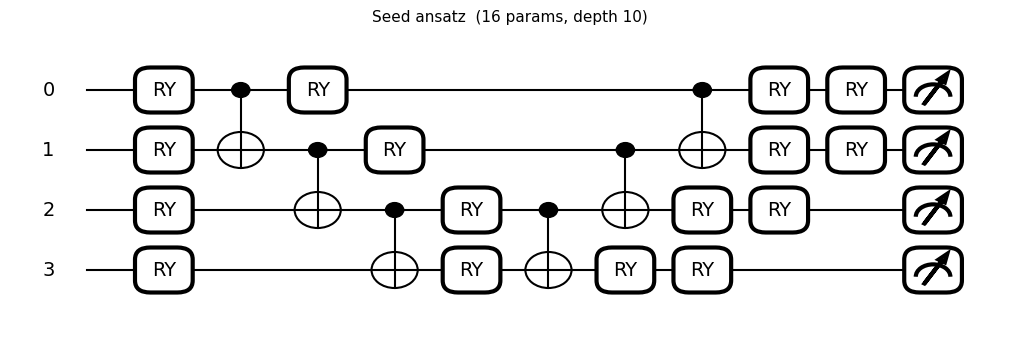

In [16]:
import evaluate
import initial_program

target_U = evaluate.generate_target_unitary()
output = initial_program.run_experiment(target_unitary=target_U, seed=0)
valid, msg = evaluate.validate_fn(output)
assert valid, f"Smoke test failed: {msg}"
print(f"Smoke test: PASSED  (fidelity={output['fidelity']:.4f}, depth={output['depth']})")

# Draw the seed ansatz
@qml.qnode(qml.device("default.qubit", wires=4))
def _draw(p):
    initial_program.ansatz(p)
    return qml.state()

fig, ax = qml.draw_mpl(_draw, decimals=None)(np.zeros(initial_program.N_PARAMS))
ax.set_title(f"Seed ansatz  ({initial_program.N_PARAMS} params, depth {output['depth']})",
             fontsize=11)
fig.set_size_inches(10, 3)
fig.tight_layout()
plt.show()

## 3. Configure and launch ShinkaEvolve

In [3]:
import datetime as dt
from time import perf_counter

from shinka.core import EvolutionConfig, ShinkaEvolveRunner
from shinka.database import DatabaseConfig
from shinka.launch import LocalJobConfig

# ── Task-specific parameters ──

TASK_SYS_MSG = """\
You are an expert in quantum computing and variational quantum algorithms.

## Task
Improve a parameterised quantum circuit (ansatz) to maximise fidelity with
a target 4-qubit unitary, while keeping the circuit shallow.

## Hardware Constraint
LINEAR CHAIN connectivity: Qubit 0 \u2014 Qubit 1 \u2014 Qubit 2 \u2014 Qubit 3

Two-qubit gates are ONLY allowed between adjacent qubits:
  (0, 1), (1, 2), (2, 3)

Any circuit using non-adjacent two-qubit gates will be REJECTED.

## Scoring
  combined_score = mean_fidelity - 0.1 * (depth / 50)

Higher is better.  Maximum fidelity is 1.0.

## Directions to Explore
- Gate variety: RY, RZ, RX for single-qubit; CNOT, CZ, CRY, CRZ for two-qubit
- Entanglement patterns: alternating forward/reverse chains, partial entanglement
- Layer depth vs. parameter efficiency tradeoff
- Trainability: shallow circuits with local entanglement avoid barren plateaus
- SWAP-based routing if you need effective long-range entanglement

## Important
- You MUST update N_PARAMS to match the number of parameters your ansatz uses.
- Keep the ansatz function signature: ansatz(params) with no return value.
- Only use PennyLane operations (qml.RY, qml.CNOT, etc.).
"""

NUM_RUNS = 3
N_STEPS = 200

os.environ["NUM_RUNS"] = str(NUM_RUNS)
os.environ["N_STEPS"] = str(N_STEPS)

experiment_name = "qml_" + dt.datetime.now().strftime("%Y%m%d_%H%M%S")
RESULTS_DIR = "results/" + experiment_name

# ── EvoConfig parameters ──

LLM_MODELS = ["openrouter/anthropic/claude-haiku-4-5",
              "openrouter/openai/gpt-5-nano"]
NUM_GENERATIONS = 30
META_LLM_MODELS = ["openrouter/openai/o4-mini"]
NOVELTY_LLM_MODELS = ["openrouter/openai/o4-mini"]
EMBEDDING_MODEL = "openrouter/openai/text-embedding-3-small"

evo_config = EvolutionConfig(
    task_sys_msg=TASK_SYS_MSG,
    init_program_path="initial_program.py",
    results_dir=RESULTS_DIR,
    language="python",
    job_type="local",
    num_generations=NUM_GENERATIONS,
    max_api_costs=1.0,
    patch_types=["diff", "full", "cross"],
    patch_type_probs=[0.6, 0.3, 0.1],
    max_patch_resamples=3,
    max_patch_attempts=2,
    llm_models=LLM_MODELS,
    llm_kwargs={"temperatures": [0, 0.5, 1.0], "max_tokens": 16384},
    llm_dynamic_selection="ucb1",
    llm_dynamic_selection_kwargs={"exploration_coef": 1.0, "cost_aware_coef": 0.7},
    meta_rec_interval=10,
    meta_llm_models=META_LLM_MODELS,
    meta_llm_kwargs={"temperatures": [0], "max_tokens": 8192},
    embedding_model=EMBEDDING_MODEL,
    max_novelty_attempts=2,
    code_embed_sim_threshold=0.99,
    novelty_llm_models=NOVELTY_LLM_MODELS,
    novelty_llm_kwargs={"temperatures": [0]},
)

# ── DBConfig parameters ──

db_config = DatabaseConfig(
    num_islands=1,
    archive_size=20,
    elite_selection_ratio=0.3,
    num_archive_inspirations=1,
    num_top_k_inspirations=1,
    parent_selection_strategy="weighted",
    parent_selection_lambda=10,
    archive_selection_strategy="crowding",
    archive_criteria={"combined_score": 1.0, "loc": -0.2},
    enable_dynamic_islands=False,
)

job_config = LocalJobConfig(
    eval_program_path="evaluate.py",
    activate_script=activate_path,
    time="00:02:00",
)

print(f"Experiment: {experiment_name}")
print(f"Generations: {NUM_GENERATIONS}, Budget: ${evo_config.max_api_costs}")
print(f"Models: {LLM_MODELS}")

Experiment: qml_20260420_104556
Generations: 30, Budget: $1.0
Models: ['openrouter/anthropic/claude-haiku-4-5', 'openrouter/openai/gpt-5-nano']


In [4]:
runner = ShinkaEvolveRunner(
    evo_config=evo_config,
    job_config=job_config,
    db_config=db_config,
    max_evaluation_jobs=2,
    max_proposal_jobs=1,
    max_db_workers=2,
    verbose=True,
)

tic = perf_counter()
await runner.run_async()
toc = perf_counter()
print(f"\nEvolution completed in {toc - tic:.1f} s")

  @@@@@@@@@@@@@@@@@@@@@      ░██████╗██╗░░██╗██╗███╗░░██╗██╗░░██╗░█████╗░
  @                   @      ██╔════╝██║░░██║██║████╗░██║██║░██╔╝██╔══██╗
  @          @        @      ╚█████╗░███████║██║██╔██╗██║█████═╝░███████║
  @    @@   @@  @@    @      ░╚═══██╗██╔══██║██║██║╚████║██╔═██╗░██╔══██║
  @   @     @    @@   @      ██████╔╝██║░░██║██║██║░╚███║██║░╚██╗██║░░██║
  @    @@  @    @     @      ╚═════╝░╚═╝░░╚═╝╚═╝╚═╝░░╚══╝╚═╝░░╚═╝╚═╝░░╚═╝
  @        @          @      @@@@@@@@@@@@@@@
  @                   @   @@                 @@@@@
  @@@@@@@@@@@@@@@@@@@@ @@                       @  @@                 █▀▀
                      @                          @@  @                ██▄
                    @      @@                      @  @@
                   @       @         @              @   @             █░█
                   @                 @               @  @             ▀▄▀
                     @@@@@          @     @           @  @
                      @            @          @ 

2026-04-20 10:45:58 - shinka.core.async_runner - INFO - 🖥️  System resources detected:

2026-04-20 10:45:58 - shinka.core.async_runner - INFO -    • CPU cores: 16

2026-04-20 10:45:58 - shinka.core.async_runner - INFO -    • Memory: 128.0 GB

2026-04-20 10:45:58 - shinka.core.async_runner - INFO - 🔧 Concurrency settings:

...

2026-04-20 10:48:28 - shinka.core.async_runner - INFO - Proposal target=2 (sampling_ewma=46.46s,                   
evaluation_ewma=2.56s, timing_samples=3, active_proposals=1, running_jobs=0)

2026-04-20 10:48:32 - shinka.core.async_runner - INFO - 🔍 Meta task check: completed_gens=4, target=30,           
pending_work=26, running_eval_jobs=0, running_proposal_jobs=1, api_costs=$0.0311/$1.00 (3.1%), should_stop=False,  
is_stuck=False, stuck_count=0, time_since_progress=9.0s

2026-04-20 10:48:45 - shinka.database.async_dbase - INFO - 🔧 Closing async database with monitoring...

2026-04-20 10:48:45 - shinka.database.async_dbase - INFO - Async database closed

CancelledError: 

## 4. Inspect results

In [7]:
import matplotlib.pyplot as plt
from shinka.utils import load_programs_to_df
from shinka.plots import plot_evals_performance, plot_lineage_tree

results_root = Path(RESULTS_DIR)
df = load_programs_to_df(str(results_root))

print(f"Total candidates evaluated: {len(df)}")
print(f"Best combined_score: {df['combined_score'].max():.4f}")

best = df.loc[df["combined_score"].idxmax()]
pub = best.get("public_metrics", {})
if isinstance(pub, dict):
    print(f"  fidelity = {pub.get('fidelity_mean', '?')}, "
          f"depth = {pub.get('depth', '?')}, "
          f"params = {pub.get('n_params', '?')}")

Total program rows: 4
Correct program rows: 4
Total cost: $0.03
Avg cost per program: $0.01
Total candidates evaluated: 4
Best combined_score: 0.1163
  fidelity = ?, depth = ?, params = ?


GraphViz not available, using hierarchical layout


/Users/allen/Projects/qml-evolve/.venv/lib/python3.12/site-packages/shinka/plots/plot_lineage_tree.py:384: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(
/Users/allen/Projects/qml-evolve/.venv/lib/python3.12/site-packages/shinka/plots/plot_lineage_tree.py:398: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


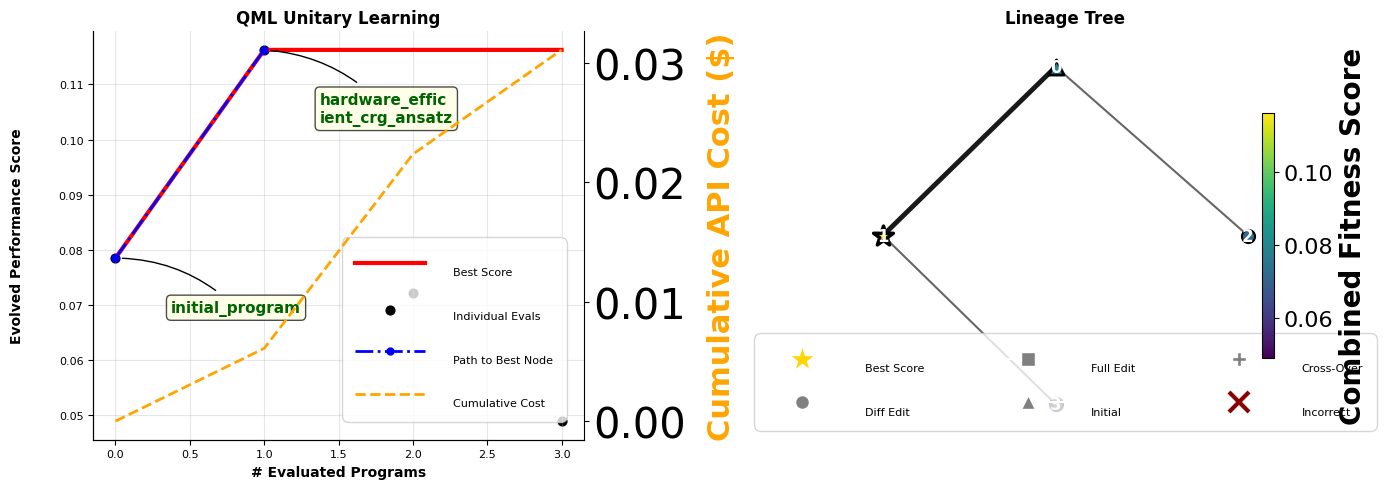

In [14]:
import matplotlib as mpl

warnings.filterwarnings("ignore", message=".*arrowsize keyword argument.*")

def rescale_fonts(ax, title=12, label=10, tick=8, legend=8):
    """Shrink hardcoded font sizes from shinka's plot helpers."""
    ax.title.set_fontsize(title)
    ax.xaxis.label.set_fontsize(label)
    ax.yaxis.label.set_fontsize(label)
    ax.tick_params(axis="both", labelsize=tick)
    leg = ax.get_legend()
    if leg:
        for t in leg.get_texts():
            t.set_fontsize(legend)
        leg.set_title(None)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_evals_performance(df, title="QML Unitary Learning", fig=fig, ax=axes[0])
plot_lineage_tree(df, title="Lineage Tree", fig=fig, ax=axes[1])
for ax in axes:
    rescale_fonts(ax)
plt.tight_layout()
plt.show()

## 5. Visualise the best evolved circuit

# EVOLVE-BLOCK-START
N_PARAMS = 18


def ansatz(params):
    """Parameterized quantum circuit ansatz on 4 qubits.

    CONNECTIVITY CONSTRAINT — linear chain: 0-1-2-3
    Two-qubit gates are ONLY allowed between adjacent qubits:
        (0,1), (1,2), (2,3)

    N_PARAMS must match the number of parameters consumed.
    """
    idx = 0
    # Layer 1: per-qubit rotations + nearest-neighbor entanglement (CRY)
    for i in range(N_QUBITS):
        qml.RY(params[idx], wires=i)
        idx += 1
    # Entangle with CRY on adjacent pairs (0-1, 1-2, 2-3)
    qml.CRY(params[idx], wires=[0, 1]); idx += 1
    qml.CRY(params[idx], wires=[1, 2]); idx += 1
    qml.CRY(params[idx], wires=[2, 3]); idx += 1

    # Layer 2: second round of per-qubit rotations
    for i in range(N_QUBITS):
        qml.RY(params[idx], wires=i)
        idx += 1
    # Layer 2 entangling with CRZ
    qml.CRZ(params[idx], wires=[0, 1]); idx += 1
    qml.CRZ(params[idx], wires=[1, 2]); idx += 1
    qml.CRZ(params[idx], wires=[2

/var/folders/j2/tr75gp992q3f99ztn21jx5rw0000gn/T/ipykernel_37761/4033624558.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_seed.tight_layout()
/var/folders/j2/tr75gp992q3f99ztn21jx5rw0000gn/T/ipykernel_37761/4033624558.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_best.tight_layout()


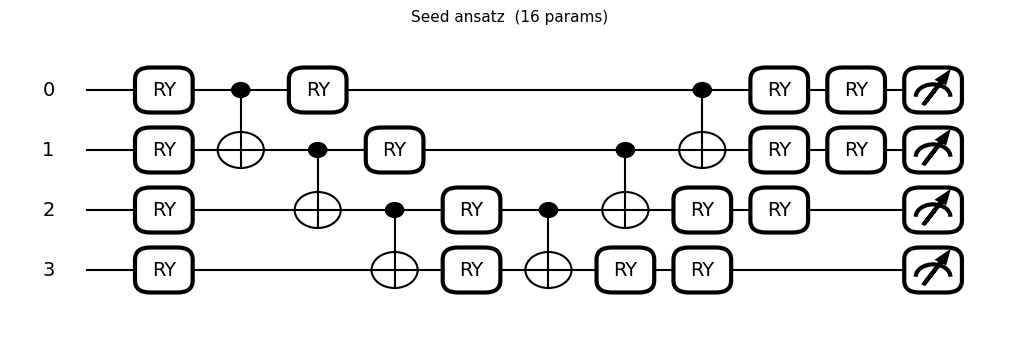

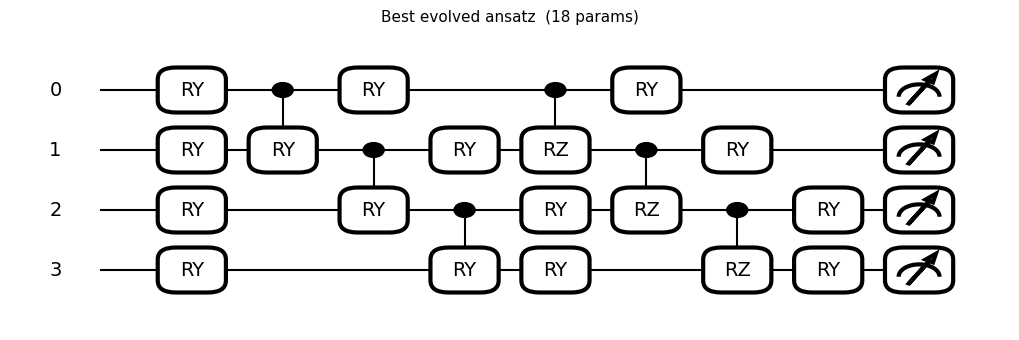

In [17]:
best_py = results_root / "best" / "main.py"

if best_py.exists():
    code = best_py.read_text()

    # Show the evolved EVOLVE-BLOCK
    start = code.find("# EVOLVE-BLOCK-START")
    end = code.find("# EVOLVE-BLOCK-END") + len("# EVOLVE-BLOCK-END")
    if start >= 0 and end > start:
        print(code[start:end])
    else:
        print(code)

    # Load the evolved module and draw the circuit
    import importlib.util
    spec = importlib.util.spec_from_file_location("best_program", best_py)
    best_mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(best_mod)

    @qml.qnode(qml.device("default.qubit", wires=4))
    def _draw_best(p):
        best_mod.ansatz(p)
        return qml.state()

    @qml.qnode(qml.device("default.qubit", wires=4))
    def _draw_seed(p):
        initial_program.ansatz(p)
        return qml.state()

    # Side-by-side comparison
    fig_seed, ax_seed = qml.draw_mpl(_draw_seed, decimals=None)(
        np.zeros(initial_program.N_PARAMS))
    fig_best, ax_best = qml.draw_mpl(_draw_best, decimals=None)(
        np.zeros(best_mod.N_PARAMS))

    ax_seed.set_title(f"Seed ansatz  ({initial_program.N_PARAMS} params)", fontsize=11)
    fig_seed.set_size_inches(10, 3)
    fig_seed.tight_layout()

    ax_best.set_title(f"Best evolved ansatz  ({best_mod.N_PARAMS} params)", fontsize=11)
    fig_best.set_size_inches(10, 3)
    fig_best.tight_layout()

    plt.show()
else:
    print(f"{best_py} not found — check RESULTS_DIR")

## Next steps

- **Different topologies:** heavy-hex (IBM), grid, or all-to-all &mdash; compare evolved ansatze
- **Larger systems:** 6&ndash;8 qubits (may need GPU simulation via `lightning.gpu`)
- **Different tasks:** VQE for molecular ground states, quantum classification
- **Multi-objective:** Pareto-optimise fidelity vs. depth vs. trainability
- **Noise-aware:** add depolarising noise, evolve noise-resilient circuits
- **Longer runs:** more generations + model ensemble (Claude + GPT + Gemini)